# 04 — Feature Engineering Audit

Phase 4 built the model-ready feature table (`src/features/build_features.py`, mirrored
in PySpark in `src/features/spark_features.py`). This notebook audits it: **is every
feature justified, and is anything leaking the target?**

## Feature rationale — nothing is arbitrary

| Feature | Grounded in |
|---|---|
| `is_new_customer` (tenure ≤ 6) | 28.1% churn cohort; bootstrap CI 17–23pp gap |
| `payment_risk` (failures ≥ 2) | threshold jump 8.7% → 21–33% |
| `low_csat` (CSAT ≤ 2) | 24–26% churn; strongest effect size (d=−0.53) |
| `inactive_30d` (> 30 days) | rate doubles past 30d; global test misses it (threshold-shaped) |
| `csat_x_payment_risk` | compound risk: 37.3% churn (Bayes analysis) |
| `risk_factor_count` | additive risk summary (0–4 flags) |
| `tenure_bucket` | non-linear lifecycle (KM curve shape) |
| `usage_minutes`, `fee_per_feature`, `support_burden`, `failures_per_year` | intensity ratios: volume × depth |
| **Dropped:** `country`, `city`, `gender` | geography independently random (49/49 uniform pairs); gender n.s. + fairness |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
FIG = ROOT / "reports" / "figures"

df = pd.read_parquet(ROOT / "data" / "processed" / "churn_features.parquet")
y = df["churn"]
X = df.drop(columns=["churn", "customer_id"])
for c in X.select_dtypes(["category", "object"]).columns:
    X[c] = X[c].astype("category")
X.shape

(10000, 37)

## Leakage audit 1 — is performance suspiciously good?

A leaked feature (one that encodes the answer) typically pushes AUC toward 1.0.
Honest tabular churn models on weak-signal data live in the 0.75–0.85 range.

In [2]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
model = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)

auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
pr = cross_val_score(model, X, y, cv=cv, scoring="average_precision")
print(f"ROC-AUC : {auc.mean():.3f} +/- {auc.std():.3f}")
print(f"PR-AUC  : {pr.mean():.3f} +/- {pr.std():.3f}   (no-skill baseline = {y.mean():.3f})")

ROC-AUC : 0.795 +/- 0.009
PR-AUC  : 0.288 +/- 0.021   (no-skill baseline = 0.102)


**Read:** ROC-AUC ≈ 0.80 and PR-AUC ≈ 0.29 (a **2.8× lift** over the 10.2% no-skill
baseline). Good but plausibly imperfect — consistent with weak-but-real signals, not with
leakage.

## Leakage audit 2 — shuffled-target sanity check

Refit on a randomly permuted target: any pipeline bug that leaks rows between folds
(or a feature computed *from* the target) would keep AUC above 0.5.

In [3]:
rng = np.random.default_rng(42)
y_shuffled = pd.Series(rng.permutation(y.values))
auc_shuffled = cross_val_score(model, X, y_shuffled, cv=cv, scoring="roc_auc")
print(f"shuffled-target ROC-AUC: {auc_shuffled.mean():.3f}  (expected ~0.50)")

shuffled-target ROC-AUC: 0.486  (expected ~0.50)


**Read:** ≈ 0.49 — a coin flip, exactly as it should be. The pipeline learns from
real structure only.

## Leakage audit 3 — does any feature dominate?

A leak usually shows up as one feature grabbing most of the model's attention.

top feature share of total importance: 8.0%


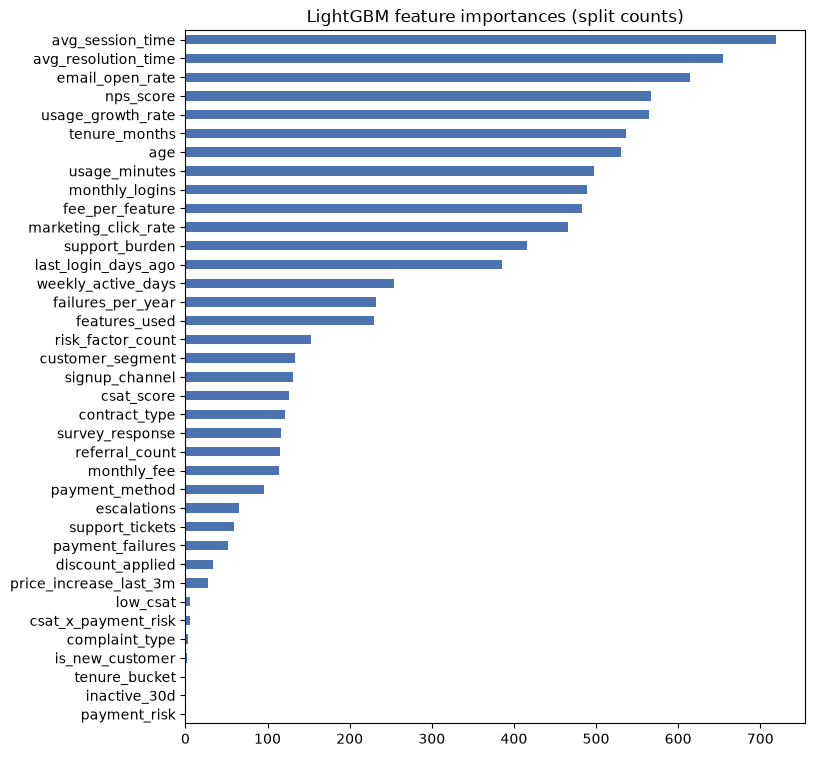

In [4]:
model.fit(X, y)
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
print(f"top feature share of total importance: {imp.iloc[-1] / imp.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 9))
imp.plot.barh(ax=ax, color="#4c72b0")
ax.set_title("LightGBM feature importances (split counts)")
fig.savefig(FIG / "10_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** the top feature holds only ~8% of total importance — attention is spread
across many weak signals, matching the statistical picture.

> **Caveat:** split-count importance systematically favours high-cardinality continuous
> features (e.g. `avg_session_time`) and under-counts binary flags — a flag can only be
> split once per path. It answers "no single leak?", not "what drives predictions?".
> Phase 6 uses **SHAP** for trustworthy attribution.

---
## Verdict

- ✅ Performance plausible (AUC 0.80), not too-good-to-be-true
- ✅ Shuffled-target ≈ 0.50 — no target leakage in the pipeline
- ✅ No dominant feature (max 8% share)
- ✅ All engineered features trace to a tested statistical finding
- 📦 Output: `data/processed/churn_features.parquet` (10,000 × 39) → Phase 5 modeling

**Note on the PySpark twin:** `spark_features.py` implements the identical logic with the
Spark DataFrame API for cluster portability (Databricks Free Edition). Local execution on
this machine is blocked by Java 26 (Spark 4 supports Java 17/21) — documented, not
hidden.